In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.57742,0.24194,13.33656,0.61061,6.964945e-111,1.283463e-108
1,ANKRD55,0.49898,0.14677,15.50163,0.56810,2.120385e-69,1.800341e-67
2,TSHZ2,0.47899,0.32903,6.40879,0.64016,1.265052e-123,2.702376e-121
3,TCEA3,0.46765,0.21613,8.13855,0.59343,7.444996e-81,8.133234e-79
4,CHRM3-AS2,0.44279,0.38065,7.00128,0.66191,1.764918e-143,4.851788e-141
5,FHIT,0.43108,0.62097,9.90167,0.77583,2.514596e-284,3.011947e-281
6,AC005842.1,0.43067,0.15887,7.74980,0.56916,1.204908e-60,8.114497e-59
7,EPHX2,0.42566,0.39435,6.96645,0.66579,6.171961e-143,1.669316e-140
8,CMTM8,0.42025,0.30645,4.82952,0.62029,2.656811e-87,3.453649e-85
9,NOG,0.38754,0.25645,9.34756,0.61520,3.898741e-112,7.304804e-110


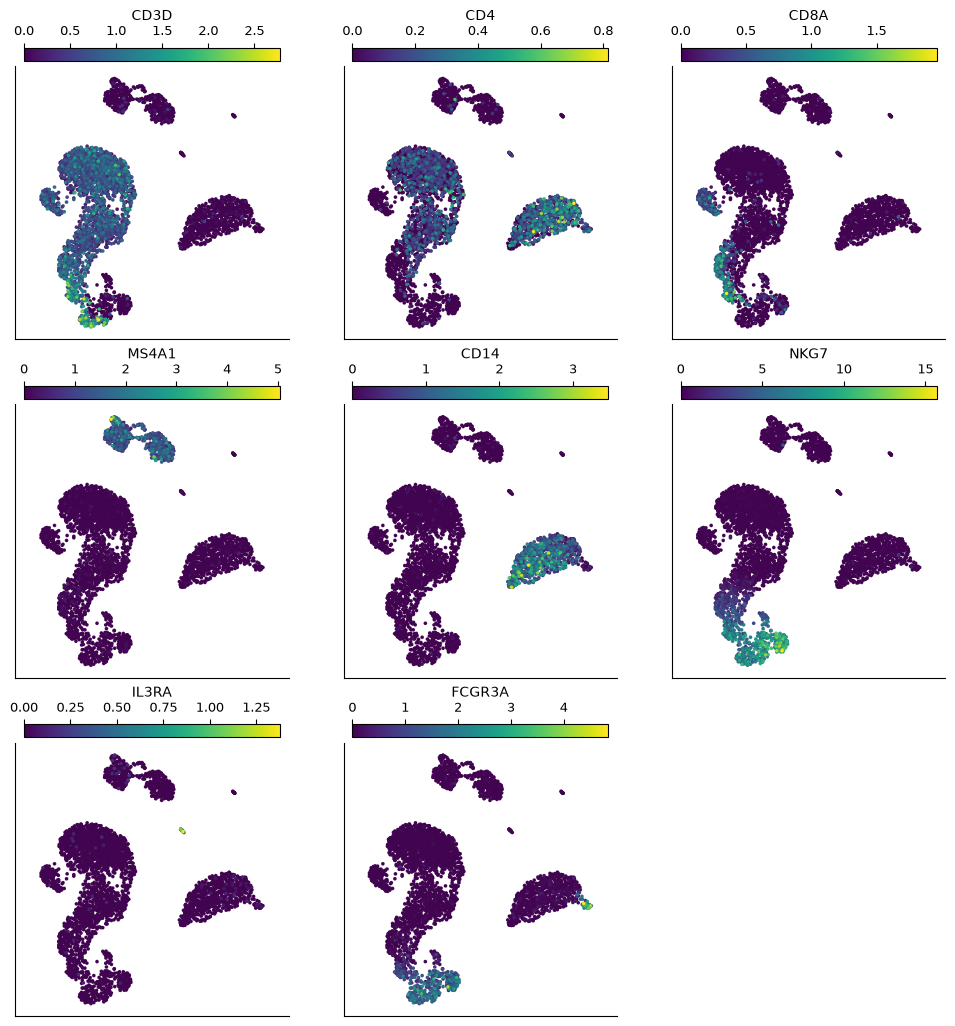

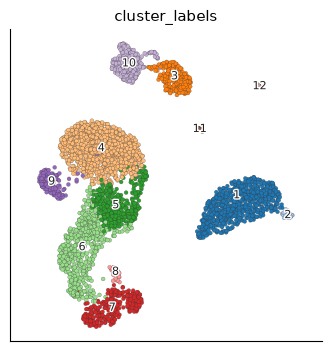

In [3]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=["CD3D", "CD4", "CD8A", "MS4A1", "CD14", "NKG7", "IL3RA", "FCGR3A"],
    n_columns=3,
    sort_values=True,
)

ds.plots.embedding(
    layout=run["umap"],
    color_by=clusters,
    legend_loc="on_data",
)

In [4]:
panel_genes = ["CD3D", "CD4", "CD8A", "MS4A1", "CD14", "NKG7", "IL3RA", "FCGR3A"]
panel_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
panel_stats = panel_markers[panel_markers["feature_name"].isin(panel_genes)]
panel_stats.pivot(index="feature_name", columns="group_id", values="score").reindex(
    panel_genes
)

group_id,1,10,11,12,2,3,4,5,6,7,8,9
feature_name,,,,,,,,,,,,
CD3D,0.00119,0.00255,0.00019,0.00019,0.00019,0.00134,0.20635,0.20511,0.24854,0.12950,0.00019,0.20468
CD4,0.32834,0.01055,0.05802,0.00054,0.20336,0.00259,0.13153,0.15539,0.08173,0.00535,0.01809,0.00451
CD8A,0.00624,0.00405,0.00517,0.00323,0.00323,0.00435,0.00746,0.01148,0.36126,0.05583,0.03766,0.50005
MS4A1,0.00290,0.48180,0.00259,0.00139,0.00161,0.48458,0.00232,0.00389,0.00786,0.00398,0.00502,0.00207
CD14,0.91362,0.00714,0.00383,0.00240,0.04743,0.00371,0.00427,0.00288,0.00317,0.00450,0.00240,0.00465
NKG7,0.01091,0.00683,0.02013,0.00046,0.02256,0.00311,0.00604,0.00760,0.19532,0.40863,0.30602,0.01238
IL3RA,0.01865,0.04304,0.78751,0.01109,0.04570,0.01109,0.01354,0.01305,0.01474,0.01427,0.01109,0.01623
FCGR3A,0.01527,0.00386,0.00275,0.00092,0.48826,0.00207,0.00168,0.00204,0.04937,0.36570,0.06671,0.00137


In [5]:
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "T cells",
    "7": "NK cells",
    "8": "NK cells",
    "9": "T cells",
    "10": "B cells",
    "11": "pDC-like cells",
    "12": "unresolved",
}
pd.Series(proposed_labels, name="proposed_cell_type")

1       CD14 monocytes
2     FCGR3A monocytes
3              B cells
4              T cells
5              T cells
6              T cells
7             NK cells
8             NK cells
9              T cells
10             B cells
11      pDC-like cells
12          unresolved
Name: proposed_cell_type, dtype: str

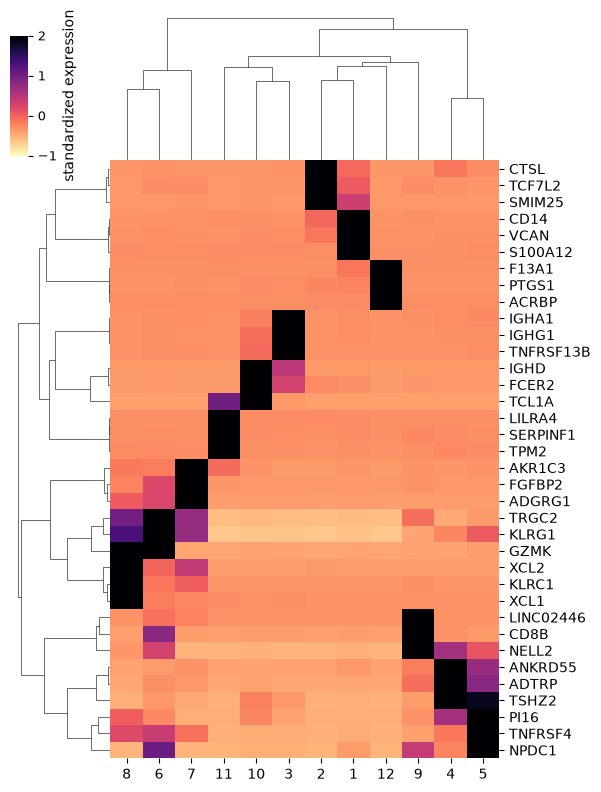

In [6]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [7]:
heatmap_genes = [
    "CD14", "VCAN", "S100A12", "CTSL", "TCF7L2", "FCER2", "IGHD",
    "IGHA1", "TNFRSF13B", "KLRF1", "FGFBP2", "GNLY", "XCL1", "GZMK", "TRGC2", "CD8A",
    "CD8B", "CD3D", "CD3E", "ADTRP", "ANKRD55", "TNFRSF4",
    "NKG7", "TCL1A", "NELL2", "LILRA4", "IL3RA", "PPBP",
]
heatmap_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
heatmap_hits = heatmap_markers[heatmap_markers["feature_name"].isin(heatmap_genes)]
heatmap_table = (
    heatmap_hits.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .sort_values("score", ascending=False)
)
heatmap_table["proposed_identity"] = (
    heatmap_table["group_id"].astype(str).map(proposed_labels)
)
heatmap_table[["feature_name", "group_id", "score", "frac_exp", "proposed_identity"]]

,feature_name,group_id,score,frac_exp,proposed_identity
0,S100A12,1,0.93899,0.95571,CD14 monocytes
1,VCAN,1,0.91826,0.98286,CD14 monocytes
2,CD14,1,0.91362,0.96857,CD14 monocytes
67076,IGHA1,3,0.84278,0.72500,B cells
67077,TNFRSF13B,3,0.82388,0.73333,B cells
201228,FGFBP2,7,0.79219,0.99647,NK cells
335382,LILRA4,11,0.78771,1.00000,pDC-like cells
335383,IL3RA,11,0.78751,1.00000,pDC-like cells
301842,IGHD,10,0.78559,0.99228,B cells
234766,XCL1,8,0.77978,0.93103,NK cells


In [8]:
neg_genes = ["CD3D", "CD3E", "CD4", "MS4A1", "CD14", ]
neg_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
neg_stats = neg_markers[neg_markers["feature_name"].isin(neg_genes)]
neg_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
2,1,CD14,0.91362,0.96857,0.98354
335201,10,CD14,0.00714,0.02703,0.41254
368382,11,CD14,0.00383,0.06667,0.43380
399135,12,CD14,0.00240,0.00000,0.40650
61570,2,CD14,0.04743,0.32000,0.54196
100483,3,CD14,0.00371,0.01667,0.40812
134019,4,CD14,0.00427,0.01694,0.37444
167629,5,CD14,0.00288,0.00484,0.39815
201180,6,CD14,0.00317,0.01033,0.39572
234650,7,CD14,0.00450,0.01767,0.40757


In [9]:
anchor_genes = ["NKG7", "GNLY", "KLRF1", "FGFBP2", "CD8A"]
anchor_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
anchor_stats = anchor_markers[anchor_markers["feature_name"].isin(anchor_genes)]
anchor_stats[["group_id", "feature_name", "score", "frac_exp", "auc"]].sort_values(
    ["feature_name", "group_id"]
)

,group_id,feature_name,score,frac_exp,auc
33309,1,CD8A,0.00624,0.01143,0.43857
335312,10,CD8A,0.00405,0.00772,0.44397
368223,11,CD8A,0.00517,0.06667,0.47380
398651,12,CD8A,0.00323,0.00000,0.44398
66740,2,CD8A,0.00323,0.00000,0.44379
100458,3,CD8A,0.00435,0.00833,0.44457
133903,4,CD8A,0.00746,0.01210,0.42690
167371,5,CD8A,0.01148,0.01937,0.44796
167694,6,CD8A,0.36126,0.40964,0.68118
233068,7,CD8A,0.05583,0.11307,0.49844


In [10]:
final_labels = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "memory B cells",
    "4": "T cells",
    "5": "CD4+ T cells",
    "6": "CD8+ T cells",
    "7": "NK cells",
    "8": "NK cells",
    "9": "CD8+ T cells",
    "10": "naive B cells",
    "11": "pDC-like cells",
    "12": "Platelets",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(final_labels)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [final_labels[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells             1240
CD8+ T cells         732
CD14 monocytes       700
CD4+ T cells         413
NK cells             312
naive B cells        259
memory B cells       240
FCGR3A monocytes      25
pDC-like cells        15
Platelets             12
Name: count, dtype: int64

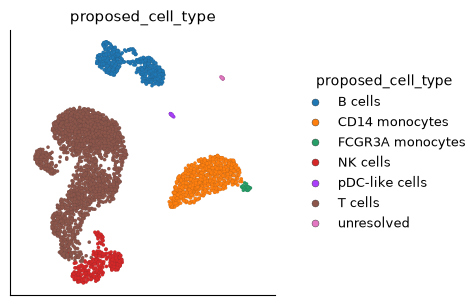

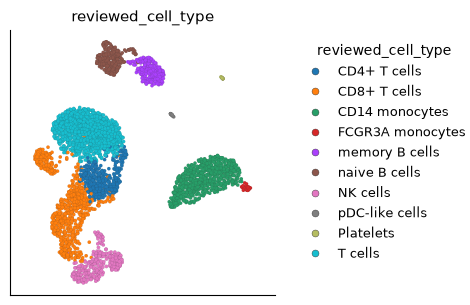

In [11]:
initial_cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
initial_cell_type[analysis_cells] = [proposed_labels[str(value)] for value in cluster_values]
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)
ds.plots.embedding(
    layout=run["umap"],
    color_by="proposed_cell_type",
    legend_loc="right",
)

ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)